In [30]:
import yaml, torch, sys
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import torch.nn.functional as F
import random as random
import re
import torch, json, random, os
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, TensorDataset
import sys
import os
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
from torch.utils.data import random_split
from types import SimpleNamespace
#add more packages here
sys.path.insert(0, '../../')
from utils.train_model import run_experiment, set_seed, get_device

In [69]:

sys.path.insert(0, '../../')
from utils.train_model import set_seed, get_device

with open('../../configs/defaults.yaml') as f:
    config = yaml.safe_load(f)

with open('../../configs/EX_03.yaml') as f:
    config.update(yaml.safe_load(f))
    
    

def to_namespace(d):
    if isinstance(d, dict):
        return SimpleNamespace(**{k: to_namespace(v) for k, v in d.items()})
    return d

config = to_namespace(config)

set_seed(config.seed)
device = get_device()

RAW_DIR  = Path(config.raw_dir)
GRAD_DIR = Path(config.grad_dir)


data_dir = Path("./EX_01/Raw/")

[device] using cuda


# Context.

This is the third experiment of the first epic. The purpose of EX_03 is to test whether our intuition is right that the model needs to learn diffusion. 

When we extended to a 4-channel input, we made the model output a mask for the digits. This meant that the only "tool" the model had was either choosing a pixel to be present or choosing not to. This made the accuracy dip terrible, far below the simple model, because the model would pretty much just give up and only show little pieces of the glphy. 

We need the model to *exploit* the blur somehow - it needs to "scatter" the information from the glyph so that the blur recovers it, which can't be done through just hiding. 

As with the previous experiment, we'll only use a fixed vertical blur for all glyphs.

# Hypothesis

Thus, our formal hypothesis is as follows:


A 3-block CNN that has access to 4 channels of the same glyph at different scales can outperform a 3- block CNN which only has access to one scale of the glyph in one channel, in terms of both pre- and post- confidence delta. If we're right on this, this will imply that moving forward with a flow-based model is the way to go.

# Implementation 

We're also going down to a kernel of 3 for the blur, the previous 9 kernel seemed too destructive

# Data

Each background is a sythentically created gradient between two random colors, in a 28x28p image. Each image will be a randomly selected item of the MNIST dataset.

For right now, we're just going to plop the mnist image (in the code called "i" or "image") over the gradient background (in the code called "b" or "background"), forming a 4-channel image (called "c" or "comp" in the code). Future experiments should expand on this by learning other combinations. 

# Notes 

# Code

In [71]:
#prep



def box_blur(x, kernel_size=config.variants.a.blur_kernel_size):
    channels = x.shape[1]
    kernel = torch.ones(channels, 1, kernel_size, kernel_size, 
                        device=x.device) / (kernel_size ** 2)
    return F.conv2d(x, kernel, padding=kernel_size//2, groups=channels)

In [73]:
#mnist classifier and data loading
#this remains a 3 channel classifier, as in both pre- and post-, we sum the image before classification
class LeNet3channel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1   = nn.Linear(16*5*5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x):
        x = F.avg_pool2d(F.relu(self.conv1(x)), 2)
        x = F.avg_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        return self.fc3(F.relu(self.fc2(F.relu(self.fc1(x)))))

def alpha_combine(b, i):
    alpha = i.expand_as(b)
    comp = alpha * i.expand_as(b) + (1 - alpha) * b
    return comp
    
def additive_combine(b, i):
    """
    b: (B, 3, H, W) background
    i: (B, 1, H, W) or (B, 3, H, W) digit
    returns: (B, 3, H, W) composite, clamped
    """
    return (b + i.expand_as(b)).clamp(0, 1)


class ex02a(Dataset):
    def __init__(self, batch_size, transform=None):
        self.pairings = pd.read_csv(Path(config.csv_path))
        self.gradients_dir = Path(config.grad_dir)
        self.transform = transform if transform is not None else transforms.ToTensor()
        self.mnist     = datasets.MNIST('../../data/', train=True, download=False,
                                        transform=transforms.ToTensor())

    def __len__(self):
        return len(self.pairings)

    def __getitem__(self, idx):
        ann = self.pairings.iloc[idx]
        if not isinstance(ann["gradient_path"], str):
            raise Exception ("huhhh")
        b_img_path =  "../EX_01/" + ann["gradient_path"]
        b = self.transform(Image.open(b_img_path).convert("RGB")) 
        i, lab = self.mnist[int(ann["mnist_idx"])]

        comp = torch.cat([b, i], dim=0)  # (4, H, W)
        return comp, lab
    
    def __getitems__(self, indices):
        return [self[i] for i in indices]

ex03a_trainset = ex02a(batch_size = config.batch_size)


n = len(ex02a_trainset)
train_size = int(0.9 * n)
val_size   = n - train_size

train_set, val_set = random_split(ex03a_trainset, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(config.seed))

#comment out for final run
# debug_size = 256*10
# train_set = torch.utils.data.Subset(train_set, random.sample(range(len(train_set)), debug_size))
# val_set   = torch.utils.data.Subset(val_set,   random.sample(range(len(val_set)),   debug_size//10))


ex03a_trainloader = DataLoader(train_set, batch_size=config.batch_size, shuffle=True)
ex03a_valloader   = DataLoader(val_set,   batch_size=config.batch_size)


In [74]:
#model
#shorthand for each cnn block
def conv_block(in_ch, out_ch, kernel, pool=True, dropout = True):
    layers = [
        nn.Conv2d(in_ch, out_ch, kernel, padding=kernel//2),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(),
        nn.Conv2d(out_ch, out_ch, kernel, padding=kernel//2),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(),
    ]
    if pool:
        layers.append(nn.MaxPool2d(2))
    if dropout: 
        layers.append(nn.Dropout(config.variants.a.dropout_rate))
    return nn.Sequential(*layers)



# def make_digit_pyramid(i, scales=[0.5, 1.25, 2, 5]):
#     # i is (B, 1, H, W)
#     B, C, H, W = i.shape
#     copies = []
#     for s in scales:
#         if s == 1.0:
#             copies.append(i)
#         else:
#             new_h, new_w = int(H * s), int(W * s)
#             scaled = F.interpolate(i, size=(new_h, new_w), mode='bilinear', align_corners=False)
#             # center crop back to original size
#             top  = (new_h - H) // 2
#             left = (new_w - W) // 2
#             copies.append(scaled[:, :, top:top+H, left:left+W])
#     return torch.cat(copies, dim=1)  # (B, 4, H, W)

def make_digit_pyramid(i, scales=[0.85, 1.2, 1.75, 3.0]):
    B, C, H, W = i.shape
    copies = []
    for s in scales:
        if s == 1.0:
            copies.append(i)
        elif s > 1.0:
            new_h, new_w = int(H * s), int(W * s)
            scaled = F.interpolate(i, size=(new_h, new_w), mode='bilinear', align_corners=False)
            top  = (new_h - H) // 2
            left = (new_w - W) // 2
            copies.append(scaled[:, :, top:top+H, left:left+W])
        else:  # s < 1.0 — scale down and pad back to original size
            new_h, new_w = int(H * s), int(W * s)
            scaled = F.interpolate(i, size=(new_h, new_w), mode='bilinear', align_corners=False)
            pad_top  = (H - new_h) // 2
            pad_left = (W - new_w) // 2
            pad_bottom = H - new_h - pad_top
            pad_right  = W - new_w - pad_left
            copies.append(F.pad(scaled, (pad_left, pad_right, pad_top, pad_bottom)))
    return torch.cat(copies, dim=1)

class threeBlockCNN7Channel(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = conv_block(7, 64, 3, pool=False, dropout=False)
        self.block2 = conv_block(64, 128, 3, pool=False, dropout=True)
        self.out    = nn.Conv2d(128, 4, 1)
    
    def forward(self, x):     
        x = self.block1(x)
        x  = self.block2(x) #will output a batchsize, 64, isize, isize
        return torch.sigmoid(self.out(x)) 

    
def ex03a_loss_fn(batch, model, mode="train", **kwargs):
    # b, i, label, b_idx, i_idx = batch
    comp, label = batch
    b, i  = comp[:, :3], comp[:, 3:]
    pyr = make_digit_pyramid(i)
    comp = torch.cat([b, pyr], dim=1)
    
    mask = model(comp)
    masked_digit = (pyr * mask).sum(dim=1, keepdim=True)
    comp  = additive_combine(b, masked_digit) 
    conf_pre, pred_pre  = m_classify_3d_with_conf(comp, label)
    
    blurred = box_blur(comp)
    conf_post, pred_post = m_classify_3d_with_conf(blurred, label)
    delta_vis = (config.variants.a.alpha * conf_pre) + (config.variants.a.beta * conf_post)
    delta_vis = (-delta_vis).mean() if delta_vis.dim() > 0 else -delta_vis
    sparsity_loss = config.variants.a.sparse_lambda * mask.mean() #added sparcity to encourage the model to do non-intrusive masks
    loss = sparsity_loss + delta_vis 
    if mode == "val":
        return {
            "val_loss":  loss.item(),
            "conf_pre":  conf_pre.mean().item(),
            "conf_post": conf_post.mean().item(),
            "delta_vis": delta_vis.mean().item()
        }
    return loss


In [75]:


# ── RUN ───────────────────────────────────────────────────────────────────────
ex03a_info = {
    "exp_id":      "EX_03a",
    "epochs":      2,
    "log_to":      "file", #"file" if you dont want wandb 
    "weights_dir": "Model/A",
    "log_dir":     "logs/A",
    "seed":        42,
    "notes": config.variants.a.description
}

model_3a = threeBlockCNN7Channel()
optimizer = torch.optim.Adam(model_2a.parameters(), lr=config.lr)

b_model = LeNet3channel().to(device)
b_model.load_state_dict(torch.load('../EX_01/Model/B/EX_01b_final.pt', map_location=device, weights_only=True))
b_model.eval()

    
# returns conf, predicted
def m_classify_3d_with_conf(image, correct):
    if image.shape[1] != 3:
        raise Exception(f"expected a 3 dim image, got a image of shape {image.shape}")
    # with torch.no_grad():
    logits = b_model(image)
    preds = torch.softmax(logits, dim=1)
    max_pred = torch.argmax(logits, dim=1)
    return preds[torch.arange(preds.shape[0]), correct], max_pred

In [ ]:
run_experiment(
    model=model_3a,
    optimizer=optimizer,
    loss_fn=ex03a_loss_fn,
    train_loader=ex03a_trainloader,
    val_loader=ex03a_valloader,
    config=ex03a_info,
    log_to=ex03a_info["log_to"],
)

[device] using cuda


[EX_03a] epoch 1/2:   2%|▏         | 23/1055 [00:06<04:55,  3.49it/s, loss=0.1615]

#Results

saved to Model/A/EX_01A_image_samples.png
exists: True
=====EX_03_A Model Pictures =========


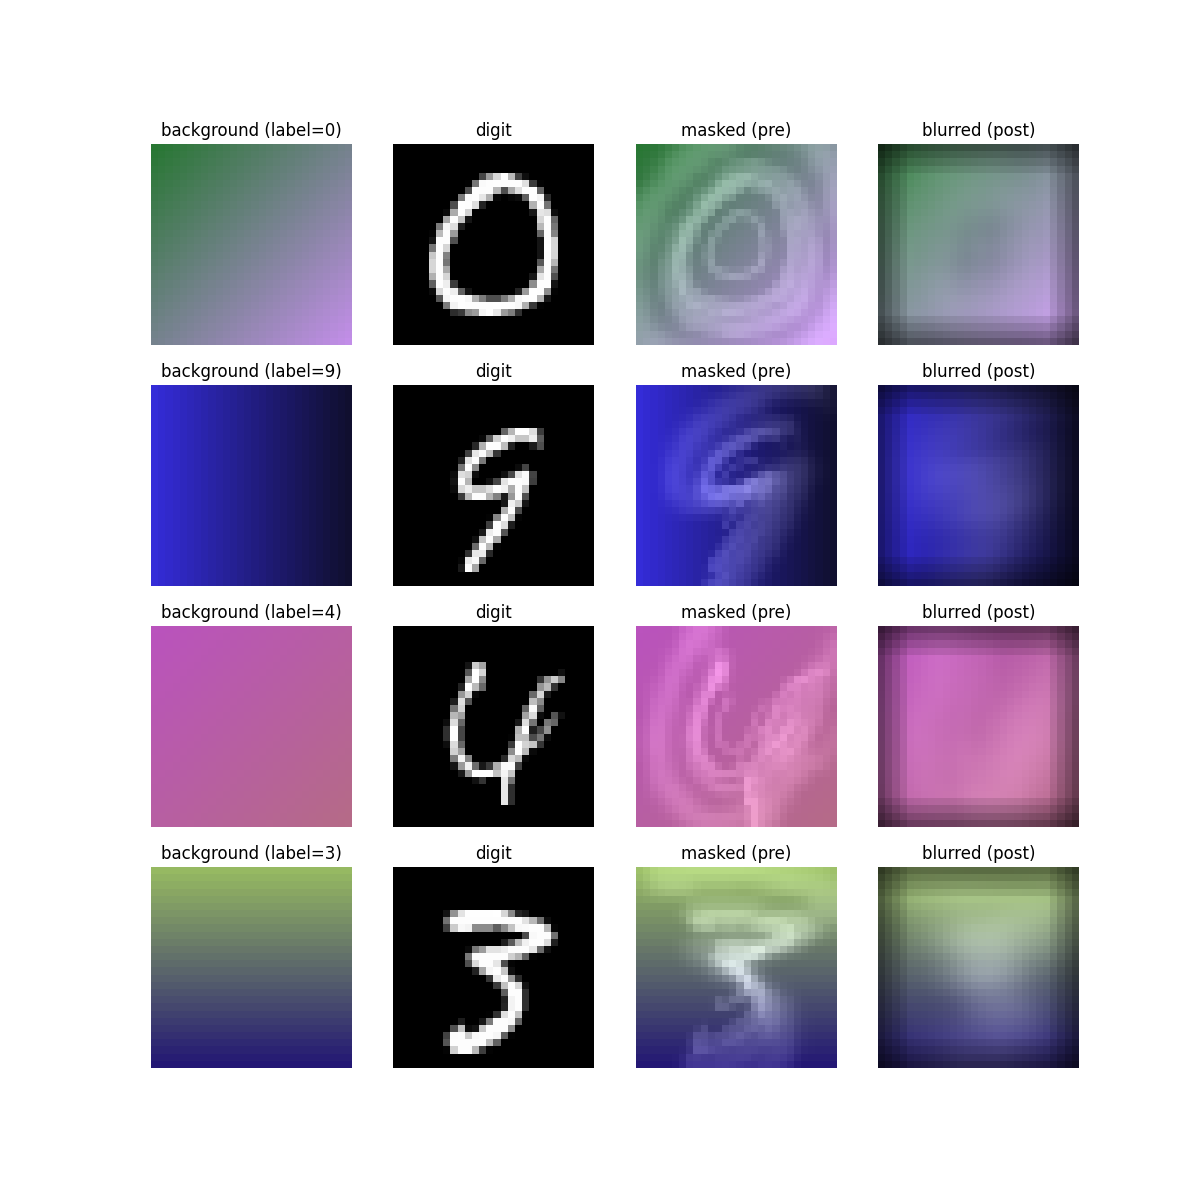

=====Masks Pictures =========


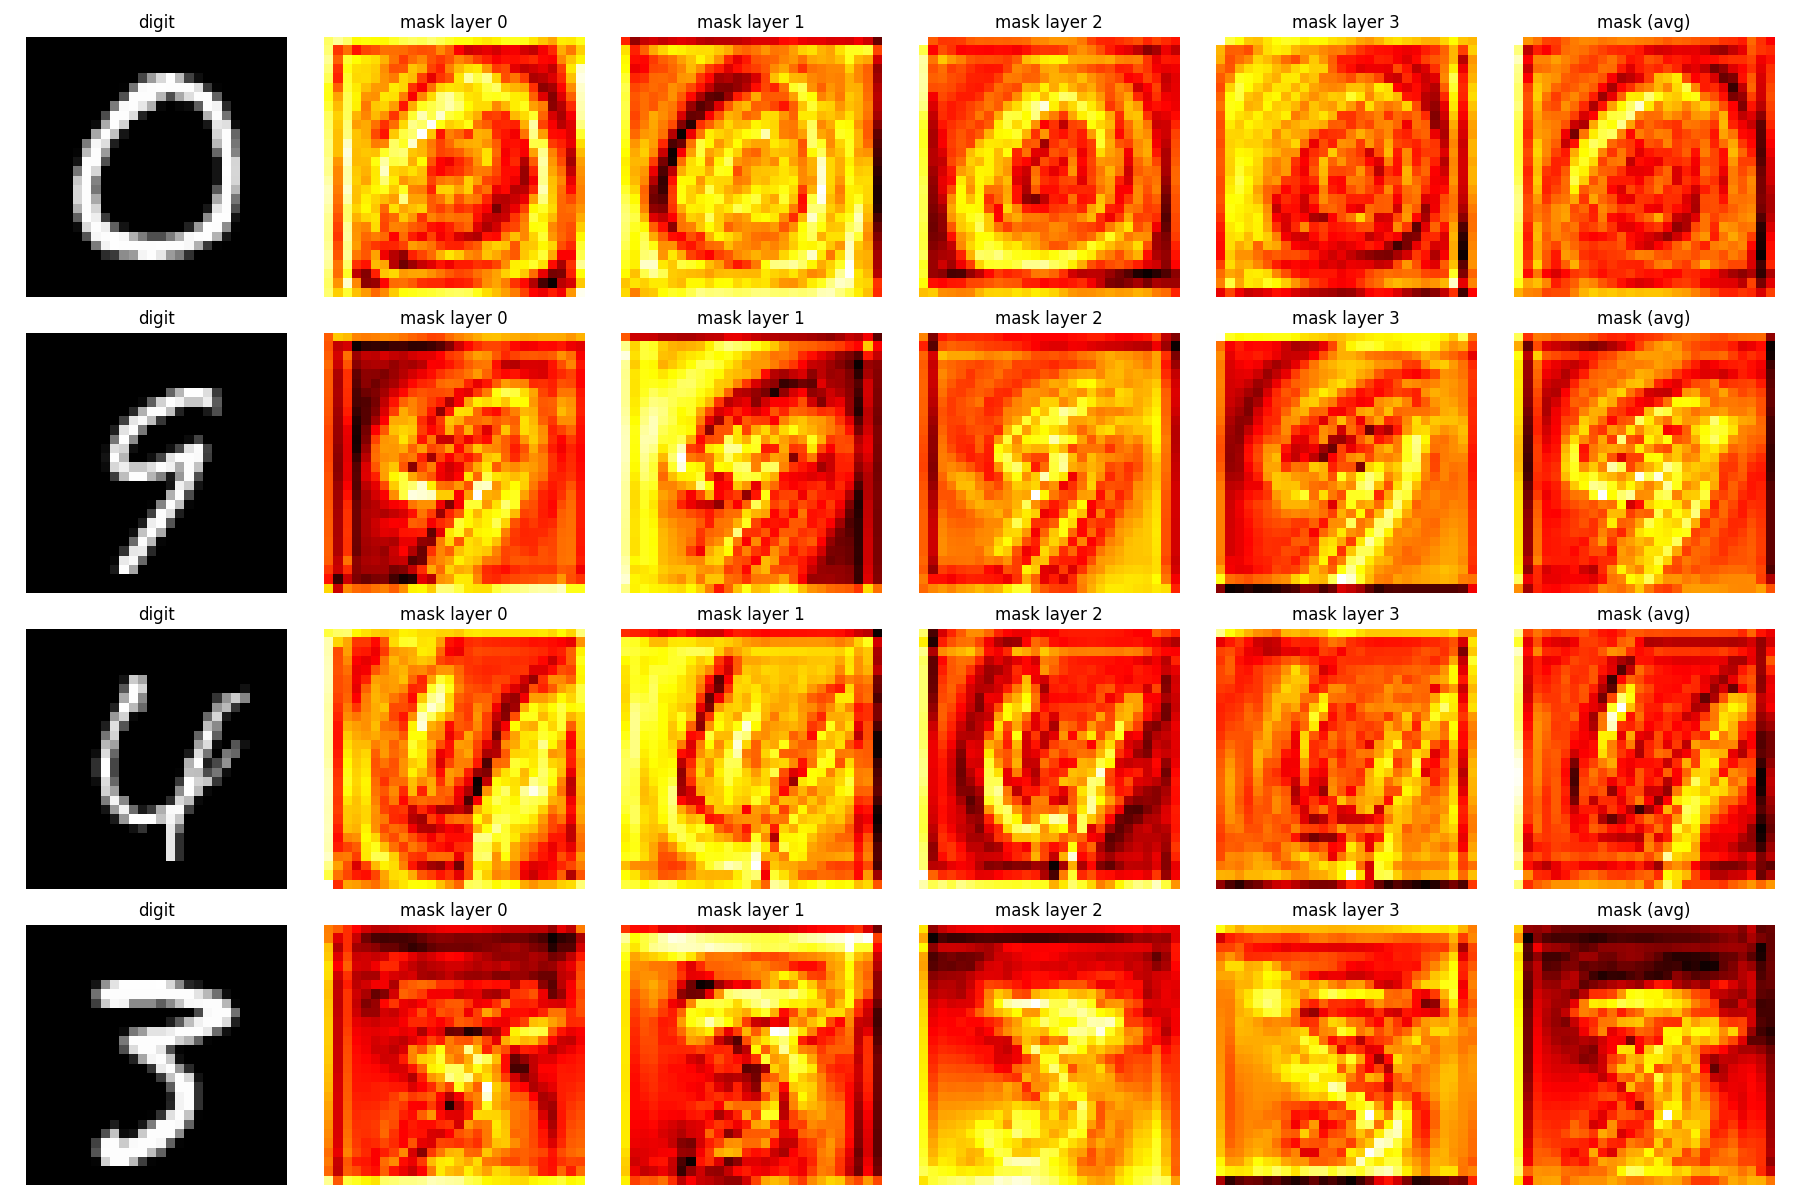

In [67]:
def show_results(model, dataset, device, variation, n=4):
    indices = random.sample(range(len(dataset)), n)
    samples = []

    # precompute all outputs once
    for idx in indices:
        comp, label = dataset[idx]
        comp_in = comp.unsqueeze(0).to(device)
        b, i = comp_in[:, :3], comp_in[:, 3:]
        with torch.no_grad():
            pyr         = make_digit_pyramid(i)
            model_input = torch.cat([b, pyr], dim=1)
            mask        = model(model_input)
            masked_digit = (pyr * mask).mean(dim=1, keepdim=True)
            composite   = additive_combine(b, masked_digit)
            blurred     = box_blur(composite)
        samples.append((comp, label, i, mask, composite, blurred))
    
    # ── VISUAL 1: input | digit | composite | blurred ────────────────────────
    fig1, axes1 = plt.subplots(n, 4, figsize=(12, n*3))
    for row, (comp, label, i, mask, composite, blurred) in enumerate(samples):
        axes1[row, 0].imshow(comp[:3].permute(1,2,0).cpu())
        axes1[row, 0].set_title(f"background (label={label})")
        axes1[row, 1].imshow(i.squeeze().cpu(), cmap="gray")
        axes1[row, 1].set_title("digit")
        axes1[row, 2].imshow(composite.squeeze(0).cpu().permute(1,2,0))
        axes1[row, 2].set_title("masked (pre)")
        axes1[row, 3].imshow(blurred.squeeze(0).cpu().permute(1,2,0))
        axes1[row, 3].set_title("blurred (post)")
        for ax in axes1[row]: ax.axis("off")
    fig1.savefig(f"Model/{variation}/EX_01{variation}_image_samples.png")
    print(f"saved to Model/{variation}/EX_01{variation}_image_samples.png")
    print(f"exists: {os.path.exists(f'Model/{variation}/EX_01{variation}_image_samples.png')}")    
    
    
    # ── VISUAL 2: digit | mask layer 0-3 | avg mask ──────────────────────────
    fig2, axes2 = plt.subplots(n, 6, figsize=(18, n*3))
    for row, (comp, label, i, mask, composite, blurred) in enumerate(samples):
        axes2[row, 0].imshow(i.squeeze().cpu(), cmap="gray")
        axes2[row, 0].set_title("digit")
        for m in range(4):
            axes2[row, m+1].imshow(mask[0, m].cpu(), cmap="hot")
            axes2[row, m+1].set_title(f"mask layer {m}")
        axes2[row, 5].imshow(mask[0].mean(dim=0).cpu(), cmap="hot")
        axes2[row, 5].set_title("mask (avg)")
        for ax in axes2[row]: ax.axis("off")
    plt.tight_layout()
    fig2.savefig(f"Model/{variation}/EX_01{variation}_mask_samples.png")
    plt.close('all')


variation = "A"
# show_masks(model_3a, ex03a_trainset, device, variation)


try:
    show_results(model_3a, ex03a_trainset, device, "A")
except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()
from IPython.display import Image as IPImage, display

print("=====EX_03_A Model Pictures =========")
display(IPImage(f"Model/{variation}/EX_01{variation}_image_samples.png"))
print("=====Masks Pictures =========")
display(IPImage(f"Model/{variation}/EX_01{variation}_mask_samples.png"))

In [34]:
!pwd

/ihome/xli/sek188/CS2770/project/blur_obfuscation_project/Epic_1/EX_03
